#### Étude des données

- Dataset d'images de tumeur du cerveau (https://www.kaggle.com/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection?resource=download)
- Images de 3 différents types de tumeurs :
    - `glioma`
    - `meningioma`
    - `pituitary`

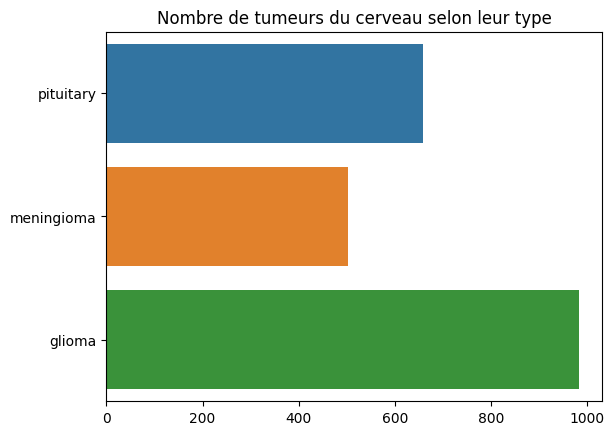

In [34]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/supervised/Yolov/brain_tumor_dataset.csv")

types = df["type"].unique()
types_occ = [len(np.where(df["type"] == t)[0]) for t in types]

sns.barplot(x=types_occ, y=types, hue=types, palette=sns.color_palette(n_colors=3))
plt.title("Nombre de tumeurs du cerveau selon leur type")
plt.show()

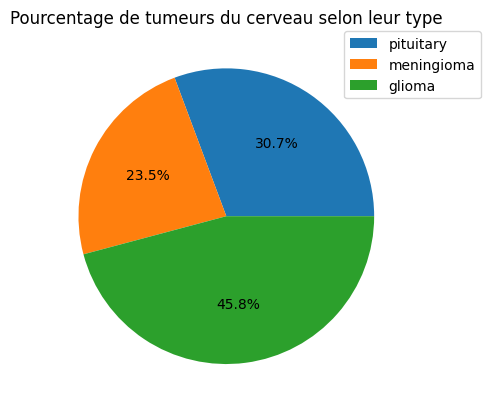

In [35]:
import matplotlib.pyplot as plt

plt.pie(x=types_occ, autopct="%1.1f%%", colors=sns.color_palette())
plt.legend(types, bbox_to_anchor=(0.8, 0.8))
plt.title("Pourcentage de tumeurs du cerveau selon leur type")
plt.show()

#### Préparation des données

- On lit les images du dataset avec la lib `matplotlib.pyplot`
- On égalise la taille de toutes les images à 640x640 sur un panel de 3 couleurs (RGB)

In [36]:
import numpy as np
import matplotlib.pyplot as plt

img_path = "BrainTumorYolov/BrainTumorYolov8/train/images/"
images = []

for _, row in df.iterrows():
    image = img_path + row["image_name"]

    img = plt.imread(image)
    img = np.resize(img, (64, 64, 2))

    images.append(img)

X = np.array(images)
y = df["type"]
X = np.array(images)
y = df["type"]

print("Nombre d'images:", len(images))
print("X:", X.shape)
print("y:", list(y.unique()))

Nombre d'images: 2144
X: (2144, 64, 64, 2)
y: ['pituitary', 'meningioma', 'glioma']


On reshape X car il avait une dimension de 4 (image) donc on l'applati pour avoir une dimension de 2 (compréhensible par les modèles de classification)

In [37]:
X_4d = X
X = X.reshape(X.shape[0], -1)
print(f"{X_4d.shape[1]} x {X_4d.shape[2]} x {X_4d.shape[3]} = {X.shape[1]}")
X.shape

64 x 64 x 2 = 8192


(2144, 8192)

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

SEED = 8
test_size = 0.1

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=SEED,
    stratify=y
)

X_valid, X_valid_test, y_valid, y_valid_test = train_test_split(
    X_test, y_test,
    test_size=test_size,
    random_state=SEED,
    stratify=y_test
)

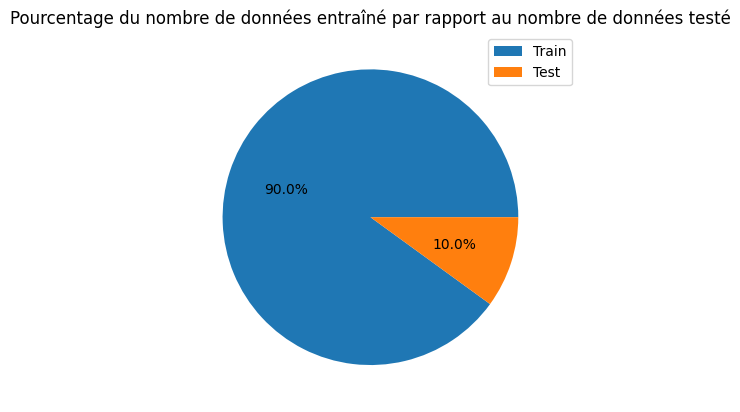

In [39]:
labels = ["Train", "Test"]
nb_test_lines = (test_size * 100) * len(df) / 100

x = [len(df) - nb_test_lines, nb_test_lines]

plt.pie(x=x, autopct="%1.1f%%", colors=sns.color_palette())
plt.legend(labels, bbox_to_anchor=(0.8, 1))
plt.title("Pourcentage du nombre de données entraîné par rapport au nombre de données testé")
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import HistGradientBoostingClassifier

In [41]:
model_rfc = RandomForestClassifier()

model_rfc.fit(X_valid, y_valid)
predict_rfc = model_rfc.predict(X_test)

TRÈS RAPIDE, TRÈS BON RÉSULTATS (~0.5s) (~97%)

In [42]:
model_ada = AdaBoostClassifier()

model_ada.fit(X_valid, y_valid)
predict_ada = model_ada.predict(X_test)

RAPIDE, BON RÉSULTATS (~3s) (~86%)

In [43]:
model_lr = LogisticRegression(max_iter=200, solver='saga')

model_lr.fit(X_valid, y_valid)
predict_lr = model_lr.predict(X_test)

/home/yohan_dupret/delivery/tek2/Projects/G-AIA-400-LIL-4-1-cvrie-13/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


RAPIDE, RÉSULTATS MAUVAIS (~5s) (~94%)

In [44]:
model_mnb = MultinomialNB()

model_mnb.fit(X_valid, y_valid)
predict_mnb = model_mnb.predict(X_test)

TRÈS RAPIDE, RÉSULTAT MAUVAIS (~0s) (~40%)

In [45]:
model_hgbc = HistGradientBoostingClassifier()

model_hgbc.fit(X_valid, y_valid)
predict_hgbc = model_hgbc.predict(X_test)

ASSÉ LENT, TRÈS BON RÉSULTATS (~14s) (~97%)

Qu'attendons-nous du modèle ? -> Qu'il sache différence les types de tumeur du cerveau.

Notre modèle doit donc :
- Savoir classer les images dans les différents types
- Être le plus rapide possible pour différente taille de dataset
- Avoir un maximum de bonne réponse dans sa classification

In [46]:
print(f"Précision RandomForestClassifier: {accuracy_score(y_test, predict_rfc) * 100:.2f}%")
print(f"Précision AdaBoostClassifier: {accuracy_score(y_test, predict_ada) * 100:.2f}%")
print(f"Précision LogisticRegression: {accuracy_score(y_test, predict_lr) * 100:.2f}%")
print(f"Précision MultinomialNB: {accuracy_score(y_test, predict_mnb) * 100:.2f}%")
print(f"Précision HistGradientBoostingClassifier: {accuracy_score(y_test, predict_hgbc) * 100:.2f}%")

Précision RandomForestClassifier: 96.74%
Précision AdaBoostClassifier: 86.98%
Précision LogisticRegression: 65.58%
Précision MultinomialNB: 39.07%
Précision HistGradientBoostingClassifier: 96.74%


## Correlation :

In [47]:
corr_train_test_df = pd.DataFrame(columns=["test_size", "score"])

In [48]:
for i in range(1, 10):
    SEED = 8
    test_size = i / 10

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=SEED,
        stratify=y
    )

    X_valid, X_valid_test, y_valid, y_valid_test = train_test_split(
        X_test, y_test,
        test_size=test_size,
        random_state=SEED,
        stratify=y_test
    )

    model = RandomForestClassifier()

    model.fit(X_valid, y_valid)

    predict = model_rfc.predict(X_test)

    score = accuracy_score(y_test, predict) * 100

    line = [str(test_size), str(round(score, 2))]

    corr_train_test_df.loc[len(corr_train_test_df)] = line
    print(f"TEST SIZE: {test_size} | SCORE: {score}")
corr_train_test_df

TEST SIZE: 0.1 | SCORE: 96.74418604651163
TEST SIZE: 0.2 | SCORE: 82.51748251748252
TEST SIZE: 0.3 | SCORE: 77.48447204968944
TEST SIZE: 0.4 | SCORE: 75.17482517482517
TEST SIZE: 0.5 | SCORE: 74.34701492537313
TEST SIZE: 0.6 | SCORE: 74.04817404817405
TEST SIZE: 0.7 | SCORE: 73.55096602265156
TEST SIZE: 0.8 | SCORE: 73.13519813519814
TEST SIZE: 0.9 | SCORE: 73.05699481865285


,test_size,score
0,0.1,96.74
1,0.2,82.52
2,0.3,77.48
3,0.4,75.17
4,0.5,74.35
5,0.6,74.05
6,0.7,73.55
7,0.8,73.14
8,0.9,73.06


<Axes: >

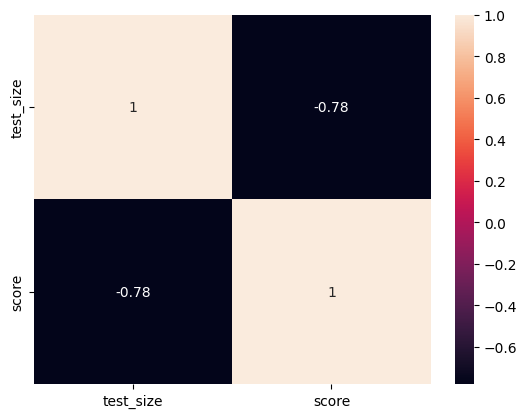

In [49]:
sns.heatmap(corr_train_test_df.corr(), annot=True)